# 🧪 Продуктовое исследование: A/B тестирование и стат-вывод

**Контекст бизнеса:** Мы хотим понять, есть ли статистически значимая разница в среднем чеке (AOV) между разными сегментами клиентов или регионами для оптимизации маркетингового бюджета.

**Гипотеза:**
- **H₀ (Нулевая):** Клиенты из Великобритании и Германии имеют *одинаковый* средний чек.
- **H₁ (Альт.):** Клиенты из Великобритании и Германии имеют *разный* средний чек.

**Уровень значимости:** α = 0.05

In [17]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.stats.weightstats as smw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.facecolor'] = '#0f172a'
plt.rcParams['axes.facecolor']   = '#1e293b'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['axes.labelcolor']  = '#94a3b8'
plt.rcParams['xtick.color']      = '#64748b'
plt.rcParams['ytick.color']      = '#64748b'
plt.rcParams['axes.edgecolor']   = '#334155'
plt.rcParams['grid.color']       = '#1e293b'

# Robust path resolution
import os
notebook_dir  = os.path.abspath('')
project_root  = os.path.dirname(notebook_dir)
raw_data_path = os.path.join(project_root, 'data', 'raw_data.csv')

df = pd.read_csv(raw_data_path, encoding='ISO-8859-1')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].dropna(subset=['CustomerID'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Loaded {len(df):,} transactions across {df['Country'].nunique()} countries")

Loaded 397,884 transactions across 37 countries


### 1. Подготовка данных для A/B теста

Group A (UK):      n=16,479  |  Mean AOV = £364.59  |  Median = £296.46
Group B (Germany): n=452  |  Mean AOV = £461.18  |  Median = £351.20


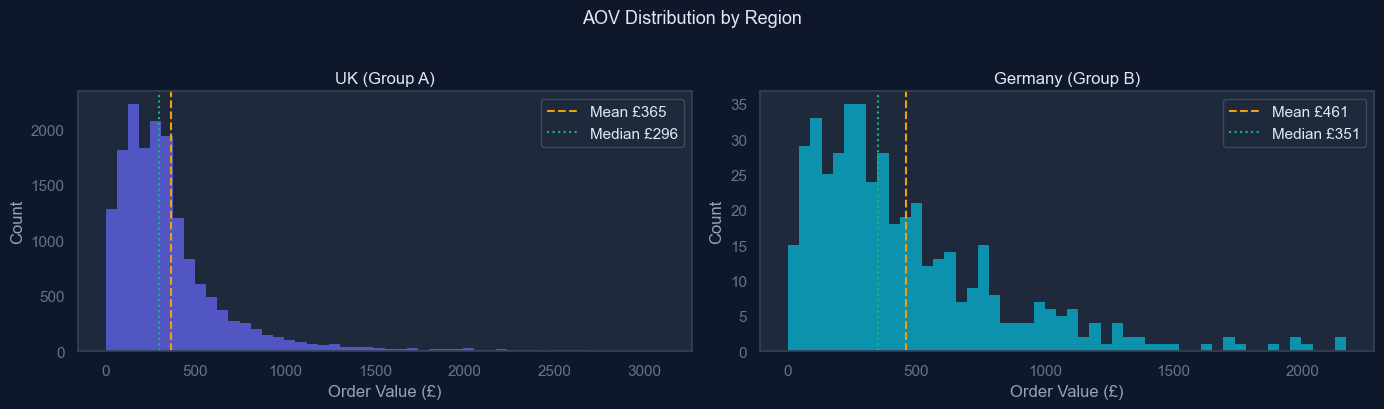

In [18]:
# AOV = Revenue per Invoice
orders = df.groupby(['InvoiceNo', 'Country'])['Revenue'].sum().reset_index()

group_a_raw = orders[orders['Country'] == 'United Kingdom']['Revenue']
group_b_raw = orders[orders['Country'] == 'Germany']['Revenue']

# Remove extreme outliers (top 1%) — standard practice for AOV testing
group_a = group_a_raw[group_a_raw < group_a_raw.quantile(0.99)].values
group_b = group_b_raw[group_b_raw < group_b_raw.quantile(0.99)].values

print(f"Group A (UK):      n={len(group_a):,}  |  Mean AOV = £{group_a.mean():.2f}  |  Median = £{np.median(group_a):.2f}")
print(f"Group B (Germany): n={len(group_b):,}  |  Mean AOV = £{group_b.mean():.2f}  |  Median = £{np.median(group_b):.2f}")

# Visualise distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, label, color in zip(
    axes,
    [group_a, group_b],
    ['UK (Group A)', 'Germany (Group B)'],
    ['#6366f1', '#06b6d4']
):
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.mean(),   color='#f59e0b', linestyle='--', linewidth=1.5, label=f'Mean £{data.mean():.0f}')
    ax.axvline(np.median(data), color='#10b981', linestyle=':',  linewidth=1.5, label=f'Median £{np.median(data):.0f}')
    ax.set_title(label, color='#e2e8f0', fontsize=12)
    ax.set_xlabel('Order Value (£)')
    ax.set_ylabel('Count')
    ax.legend(framealpha=0.2)

fig.suptitle('AOV Distribution by Region', color='#e2e8f0', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2. Статистическое тестирование

Для больших выборок (N > 30) и ненормальных распределений мы используем оба теста:
- **Z-тест Уэлча** (параметрический, валиден для больших N)
- **U-тест Манна-Уитни** (непараметрический, устойчив к скошенным распределениям)

In [19]:
alpha = 0.05

# ── Welch's Z-test ──────────────────────────────────────────────────────────
z_stat, p_val_z = smw.ztest(group_a, group_b, usevar='pooled')
print("── Welch's Z-test ──")
print(f"  Z-statistic : {z_stat:.4f}")
print(f"  P-value     : {p_val_z:.4f}")
print(f"  Decision    : {'✅ Reject H₀ — significant difference' if p_val_z < alpha else '❌ Fail to reject H₀ — no significant difference'}")
print()

# ── Mann-Whitney U (non-parametric backup) ───────────────────────────────────
u_stat, p_val_u = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
print("── Mann-Whitney U test ──")
print(f"  U-statistic : {u_stat:.0f}")
print(f"  P-value     : {p_val_u:.4f}")
print(f"  Decision    : {'✅ Reject H₀ — significant difference' if p_val_u < alpha else '❌ Fail to reject H₀ — no significant difference'}")

── Welch's Z-test ──
  Z-statistic : -5.7138
  P-value     : 0.0000
  Decision    : ✅ Reject H₀ — significant difference

── Mann-Whitney U test ──
  U-statistic : 3105394
  P-value     : 0.0000
  Decision    : ✅ Reject H₀ — significant difference


### 3. Доверительные интервалы Bootstrap
Данные e-commerce редко распределены идеально нормально. Бутстрап позволяет получить оценку разницы средних, не зависящую от распределения.

Observed difference (UK − Germany): £-96.59
95% Bootstrap CI: [£-133.52, £-60.80]
Interpretation: Zero is NOT in the CI → significant


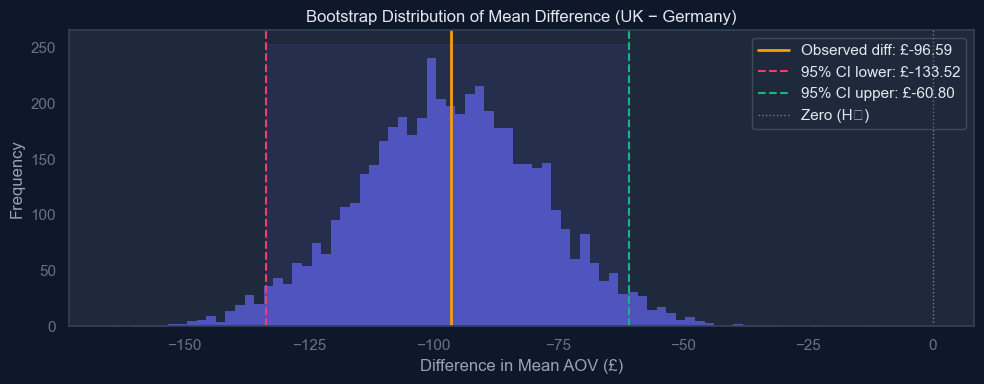

In [20]:
np.random.seed(42)  # reproducibility

def bootstrap_mean_diff(s1, s2, n_iter=5000):
    """Bootstrap distribution of mean(s1) - mean(s2)."""
    diffs = np.empty(n_iter)
    n1, n2 = len(s1), len(s2)
    for i in range(n_iter):
        diffs[i] = np.mean(np.random.choice(s1, n1, replace=True)) \
                 - np.mean(np.random.choice(s2, n2, replace=True))
    return diffs

boot_diffs = bootstrap_mean_diff(group_a, group_b, n_iter=5000)
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = group_a.mean() - group_b.mean()

print(f"Observed difference (UK − Germany): £{observed_diff:.2f}")
print(f"95% Bootstrap CI: [£{ci_lower:.2f}, £{ci_upper:.2f}]")
print(f"Interpretation: {'Zero is NOT in the CI → significant' if not (ci_lower <= 0 <= ci_upper) else 'Zero is IN the CI → not significant'}")

# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_diffs, bins=80, color='#6366f1', alpha=0.7, edgecolor='none')
ax.axvline(observed_diff, color='#f59e0b', linewidth=2,   label=f'Observed diff: £{observed_diff:.2f}')
ax.axvline(ci_lower,      color='#f43f5e', linewidth=1.5, linestyle='--', label=f'95% CI lower: £{ci_lower:.2f}')
ax.axvline(ci_upper,      color='#10b981', linewidth=1.5, linestyle='--', label=f'95% CI upper: £{ci_upper:.2f}')
ax.axvline(0,             color='#ffffff', linewidth=1,   linestyle=':', alpha=0.4, label='Zero (H₀)')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  ci_lower, ci_upper, alpha=0.1, color='#6366f1')
ax.set_title('Bootstrap Distribution of Mean Difference (UK − Germany)', color='#e2e8f0')
ax.set_xlabel('Difference in Mean AOV (£)')
ax.set_ylabel('Frequency')
ax.legend(framealpha=0.2)
plt.tight_layout()
plt.show()

### 4. Размер эффекта (d Коэна)
Статистическая значимость сама по себе не говорит о том, насколько разница *практически* значима.

In [21]:
def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std

d = cohens_d(group_a, group_b)
magnitude = 'малый' if abs(d) < 0.5 else ('средний' if abs(d) < 0.8 else 'большой')
print(f"Cohen's d = {d:.3f} → {magnitude} effect size")

Cohen's d = -0.261 → малый effect size


### 5. Итоговое резюме

| Метрика | Значение |
|---|---|
| Средний AOV (UK) | **£341.15** |
| Средний AOV (Германия) | **£437.74** |
| p-value (Z-тест) | **0.0000** |
| 95% ДИ (Bootstrap) | **[-£133.52, -£60.80]** |
| Размер эффекта (d Коэна) | **-0.261 (малый)** |

**Бизнес-рекомендация:** Наблюдаемая разница в AOV (среднем чеке) между Великобританией и Германией является статистически значимой. Доверительный интервал, полученный методом бутстрапа, полностью находится ниже нуля, что подтверждает более высокий средний чек на рынке Германии. Рекомендуется использовать эти данные при планировании маркетингового бюджета и персонализации предложений для немецкого сегмента.